# LAB02 Assigment Template




### Exercise 0  Importing the census 

In [13]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from time import time
from IPython.display import display  # Allows the use of display() for DataFrames

# Pretty display for notebooks
%matplotlib inline

data = pd.read_csv("census.csv") 
# read the census data from a CSV file and store it in a DataFrame called 'data'

data.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


### Exercise 1  Exploration 

In [14]:
# The total number of records
n_records = data.shape[0]
# data.shape[0] gives the number of rows
# which corresponds to the total number of records

print("Total number of records: {}".format(n_records))

Total number of records: 45222


In [15]:
# The number of individuals making more than $50000 annually
n_greater_50k = (data["income"].str.strip() == ">50K").sum()
# data["income"] accesses the 'income' column of the DataFrame
# .str.strip() removes any leading or trailing whitespace
# from the string values in the 'income' column
# == ">50K" creates a boolean Series
# where True indicates individuals making more than $50K
# .sum() counts the number of True values in the boolean Series
# giving the total number of individuals making more than $50K annually

print("Number of individuals making more than $50,000 annually: {}".format(n_greater_50k))

Number of individuals making more than $50,000 annually: 11208


In [16]:
# The number of individuals making at most $50000 annually
n_at_most_50k = (data["income"].str.strip() == "<=50K").sum()
# data["income"]: access the 'income' column
# strip: means remove whitespace from the string values
# == "<=50K": boolean series with true and false values
# sum: counts the number of true values in the boolean series
# that gives the total number of individuals making at most $50K annually

print("Number of individuals making at most $50,000 annually: {}".format(n_at_most_50k))

Number of individuals making at most $50,000 annually: 34014


In [17]:
# The percentage of individuals making at more than $50000 annually
greater_percent = (n_greater_50k / n_records) * 100
# n_greater_50k: number of individuals making more than $50K
# n_records: total number of records
# (n_greater_50k / n_records) gives the fraction
# multiplying by 100 converts the fraction to a percentage

print("Percentage of individuals making more than $50,000 annually: {:.2f}%".format(greater_percent))
# {:.2f}% formats the percentage to two decimal places

Percentage of individuals making more than $50,000 annually: 24.78%


### Exercise 2 Preprocessing 

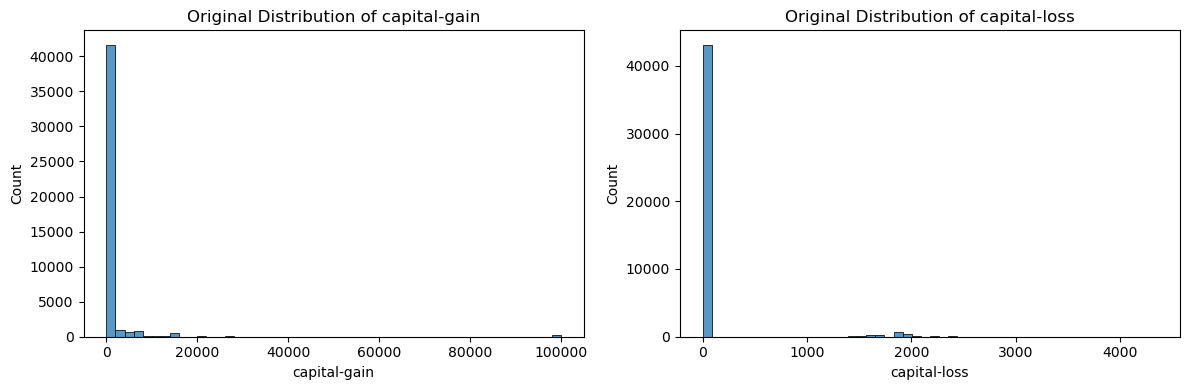

In [18]:
# Visualize skewed continuous features of original data
import seaborn as sns
# seaborn is a data visualization library based on matplotlib
import matplotlib.pyplot as plt
# matplotlib is a plotting library for creating static, animated
# and interactive visualizations in Python

skewed = ["capital-gain", "capital-loss"]
# skewed is a list of column names that represent skewed continuous features

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# create a figure and a set of subplots with 1 row and 2 columns
# figsize=(12, 4) sets the size of the figure

# loop through the skewed features and create a histogram for each
for i, col in enumerate(skewed):
    sns.histplot(data[col], bins=50, ax=axes[i], kde=False)
    # create a histogram of the specified column
    # bins=50 sets the number of bins
    # which determines the granularity of the histogram
    # ax=axes[i] specifies the subplot to draw the histogram on
    # kde=False disables the kernel density estimate overlay

    axes[i].set_title(f"Original Distribution of {col}")
    # set the title of the subplot

plt.tight_layout()
# adjust the padding between and around subplots to prevent overlap

plt.show()
# display the figure with the histograms

# we can see that the distributions of 'capital-gain' and 'capital-loss' are highly skewed
# with a long tail towards the right for 'capital-gain' and towards the left for 'capital-loss'
# loss is showed to be positive but actually negative
# so it seems like right skewed but it is actually left skewed

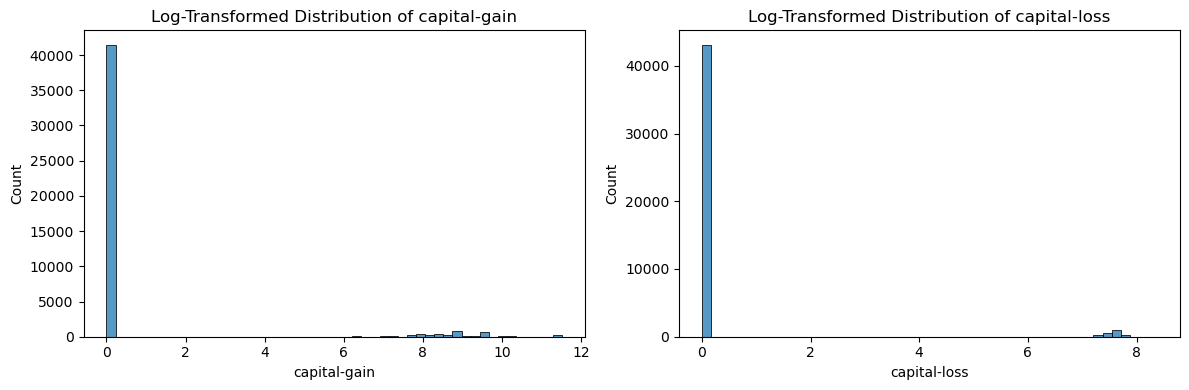

In [19]:
# Outliers Treatment (logarithmic transformation)

income_raw = data["income"].copy()
# create a copy of the 'income' column

features_raw = data.drop("income", axis=1)
# create a new DataFrame 'features_raw'
# by dropping the 'income' column from the original DataFrame 'data'
# axis=1 specifies that we want to drop a column
# instead of dropping a row (axis=0)

features_log_transformed = features_raw.copy()
# create a copy of 'features_raw' to apply log transformation

features_log_transformed[skewed] = features_log_transformed[skewed].apply(lambda x: np.log1p(x))
# features_log_transformed[skewed] selects the columns specified in the 'skewed' list
# .apply(lambda x: np.log1p(x)) applies a lambda function to each of the selected columns
# np.log1p(x) computes the natural logarithm of (1 + x)
# this transformation is used to handle skewed data and reduce the impact of outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(skewed):
    sns.histplot(features_log_transformed[col], bins=50, ax=axes[i], kde=False)
    axes[i].set_title("Log-Transformed Distribution of {}".format(col))
plt.tight_layout()
plt.show()

# now we see that the distributions of 'capital-gain' and 'capital-loss' 
# are more normalized after applying the logarithmic transformation
# the long tails have been reduced, making the data more suitable for modeling

In [20]:
# Data Transformation
from sklearn.preprocessing import MinMaxScaler
# MinMaxScaler is a preprocessing technique from the scikit-learn library

scaler = MinMaxScaler()
# Fit the scaler to the log-transformed features and transform them
numerical = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
# numerical is a list of column names that represent numerical features

features_log_minmax_transform = features_log_transformed.copy()
# create a copy of 'features_log_transformed' to apply MinMax scaling
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])
# scaler.fit_transform() fits the MinMaxScaler to the specified numerical columns
# and transforms the data by scaling each feature to a given range (default is 0 to 1)
# the transformed features are stored back in the 'features_log_minmax_transform' DataFrame

# Perform one-hot encoding on the data
features_final = pd.get_dummies(features_log_minmax_transform)
# features_final is a new DataFrame created by applying 
# one-hot encoding to the 'features_log_minmax_transform' DataFrame
# get_dummies() converts categorical variables into dummy/indicator variables

income = income_raw.str.strip().map({"<=50K": 0, ">50K": 1})
# .str.strip() removes any leading or trailing whitespace from the string values
# .map({"<=50K": 0, ">50K": 1}) maps the string values to binary values

print("Processed features shape: {}".format(features_final.shape))
display(features_final.head())
display(income.head())


Processed features shape: (45222, 103)


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.301370,0.800000,0.667492,0.0,0.397959,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.452055,0.800000,0.000000,0.0,0.122449,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,0.287671,0.533333,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.493151,0.400000,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.150685,0.800000,0.000000,0.0,0.397959,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

### Exercise 3 Shuffle and Split Data

In [21]:
# Split the 'feature' and 'income' data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_final, # features_final is the DataFrame containing the processed features
    income, # income is the Series containing the target variable (binary labels)
    test_size=0.2, 
    # test_size=0.2 means that 20% of the data will be used for testing and 80% for training
    random_state=42, # random_state=42 ensures reproducibility of the results
    stratify=income 
    # stratify=income ensures that the proportion of each class is maintained
    # in both training and testing sets
)

print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training set has 36177 samples.
Testing set has 9045 samples.
X_train shape: (36177, 103)
X_test shape: (9045, 103)
y_train shape: (36177,)
y_test shape: (9045,)


### Exercise 4 A Simple Model

In [22]:
from sklearn.metrics import accuracy_score, f1_score
# accuracy_score is a metric that calculates the ratio of correctly predicted samples to the total number of samples
# f1_score is a metric that calculates the harmonic mean of precision and recall
import numpy as np
# numpy is a library for numerical computing in Python, providing support for arrays and mathematical functions

y_pred_all_positive = np.ones_like(y_test)
# np.ones_like(y_test) creates an array of the same shape as y_test filled with ones
# this represents a baseline model that predicts all samples as the positive class (income > 50K)

accuracy = accuracy_score(y_test, y_pred_all_positive)
f_score = f1_score(y_test, y_pred_all_positive)
# we use the accuracy_score and f1_score function
# to evaluate the performance of the baseline model

print("Simple model (always predict >50K)")
print("Accuracy: {:.4f}".format(accuracy))
print("F-score (F1): {:.4f}".format(f_score))

Simple model (always predict >50K)
Accuracy: 0.2479
F-score (F1): 0.3973


### Exercise 5 Evaluating Model 

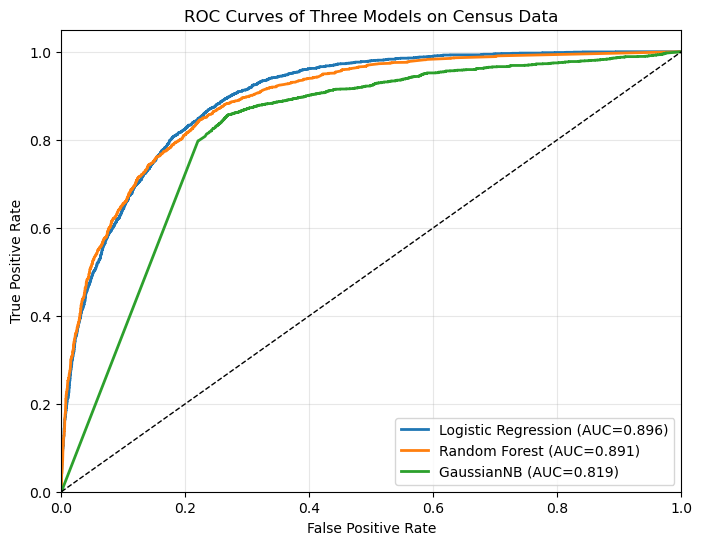

,Model,Accuracy,F1-score,AUC
0,Logistic Regression,0.839801,0.642311,0.896422
1,Random Forest,0.842786,0.661429,0.890516
2,GaussianNB,0.603096,0.536176,0.818720


In [23]:
# Exercise 5: Evaluate 3 supervised models with ROC curves

import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score
import pandas as pd
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GaussianNB": GaussianNB()
}

results = []

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        raw_score = model.decision_function(X_test)
        y_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())

    y_pred = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-score": f1,
        "AUC": roc_auc
    })

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Three Models on Census Data")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
display(results_df)